# Receiver Function Inversion with the Neighbourhood Algorithm

[![Open In Colab](https://img.shields.io/badge/open%20in-Colab-b5e2fa?logo=googlecolab&style=flat-square&color=ffd670)](https://colab.research.google.com/github/inlab-geo/cofi-examples/blob/main/examples/receiver_function/receiver_function_neighpy.ipynb)

> If you are running this notebook locally, make sure you've followed [steps here](https://github.com/inlab-geo/cofi-examples#run-the-examples-with-cofi-locally)
to set up the environment. (This [environment.yml](https://github.com/inlab-geo/cofi-examples/blob/main/envs/environment.yml) file
specifies a list of packages required to run the notebooks)

## Table of contents

1. [Introduction](#introduction)
   1. [Receiver functions](#receiver-functions)
   2. [Neighbourhood Algorithm](#na)
   3. [CoFI and the NA](#cofiandna)
2. [Import modules](#import)
3. [Define the problem](#problemsetup)
4. [Problem 1: Invert for velocities only](#problem1)
   1. [Stage I: Direct Search](#p1-stage1)
   2. [Stage II: Appraisal](#p1-stage2)
5. [Problem 2: Invert for depths and velocities](#problem2)
   1. [Stage I: Direct Search](#p2-stage1)
   2. [Stage II: Appraisal](#p2-stage2)

***

## 1. Introduction <a name="introduction"></a>

### 1.1 Receiver functions <a name="receiver-functions"></a>

In [1]:
# display theory on receiver functions
from IPython.display import display, Markdown

with open("../../theory/geo_receiver_function.md", "r") as f:
    content = f.read()

display(Markdown(content))

Receiver functions are a class of seismic data used to study discontinuities (layering) in the Earth's crust. At each discontinuity, P-to-S conversions occur, introducing complexity in the waveform. By deconvolving horizontal- and vertical-channel waveforms from earthquakes at teleseismic distances, we can isolate information about these conversions, and hence learn about the crustal structure. This deconvolved signal is the receiver function, and has a highly non-linear dependence on the local crustal properties.

We refer you to the paper below for description of the algorithms and the forward kernel we use:

*Genetic algorithm inversion for receiver functions with application to crust and uppermost mantle structure beneath Eastern Australia*,
Shibutani, T., Kennett, B. and Sambridge, M., Geophys. Res. Lett., 23 , No. 4, 1829-1832, 1996.

In order to better understand the complexity and non-linear nature of seismic receiver function inversion, we have included a few illustrative animations. These animations highlight the substantial influence of velocities and, more prominently, interface depths on the resulting receiver functions.

This is a non-linear problem which can be highly sensitive to the starting model. 


<figure>
    <img src="https://github.com/inlab-geo/cofi-examples/blob/main/theory/illustrations/depth_layer3_anim4.gif?raw=true"
         alt="Animation of Receiver function misfit surface" width="600"/>
    <figcaption>Animation showing variation of Receiver function misfit with a change in layer thicknesses and velocities. Here the misfit is multi-modal.</figcaption>
</figure>

<figure>
    <img src="https://github.com/inlab-geo/cofi-examples/blob/main/theory/illustrations/vel_layer3_anim4_400f.gif?raw=true"
         alt="Animation of Receiver function misfit surface" width="600"/>
    <figcaption>Animation showing variation of Receiver function misfit with a change of velocity with a single layer. Here the misfit is near quadratic.</figcaption>
</figure>



<figure>
    <img src="https://github.com/inlab-geo/cofi-examples/blob/main/theory/illustrations/3Dsurf_x40y10_v55_l270_35.png?raw=true"
         alt="Receiver function misfit surface" width="600"/>
    <figcaption>A misfit function showing similarity between a predicted and observed Receiver function.</figcaption>
</figure>

### 1.2 Neighbourhood Algorithm <a name="na"></a>

In [2]:
# display theory on the Neighbourhood Algorithm
from IPython.display import display, Markdown

with open("../../theory/neighbourhood_algorithm.md", "r") as f:
    content = f.read()

display(Markdown(content))

### 1.1 Neighbourhood Algorithm <a name="na"></a>

The Neighbourhood Algorithm (NA) is described in two papers ([Sambridge, 1999a]() and [Sambridge, 1999b]()) and became popular for geophysical inverse problems.
We give a breif summary of the NA here for intuition.

It can be divided into two main phases:
1. Direct Search Phase
2. Appraisal Phase

As decribed in the papers, these phases use geometrical structures called Voronoi cells to define neighbourhoods of parameter space within which the value of the objective function is constant.
These neighbourhoods are then repeatedly sampled and refined to find the optimum position in the parameter space.

#### Direct Search Phase

This is a derivative-free optimisation aglorithm that results in an ensemble of points/samples/neighbourhoods distributed according to the objective function being solved.
More dense regions of points correspond to the more optimum areas of the objective function.

In brief, the phase algorithm progresses as follows:
1. Create an initial ensemble (of size $n_i$) of points by uniformly sampling the parameter space
2. Interate $n$ times:
   1. Rank the ensemble according to the objective function
   2. Select the best $n_r$ points in the ensemble to be resampled
   3. Resample the neighbourhoods/Voronoi cells of best $n_r$ points to obtain $n_s$ new samples
   4. Add the new samples to the ensemble

In the original papers the resampling is performed using a Gibbs sampler, although in theory any sampling algorithm can be used within each neighbourhood - the trick is in computing the neighbourhoods.

The result of this phase is a large ensemble of size $N = n_i + n \times n_s$ and their associated objective values, effectivly a discretisation of the objective function.

#### Appraisal Phase

This phase is used to reffine an ensemble of points, and produce new samples that are distributed according to the posterior distribution function.
Effectively, this is just a Bayesian sampling of a step-wise constant posterior.
In theory any sampling approach can be used to create the ensemble to be refined, and any sampling approach can be used to do the refining.
In the original papers the initial ensemble is created using the Direct Search Phase, and the refining is done with a Gibbs sampler.

A key advantage of this phase is that it avoids computing the forward function for all the new samples.
So if you have already partially sampled the parameter space but the forward function is too slow that your initial method will take too long to get a sufficient number of samples, you can use the appraisal phase of the NA.



### 1.3 CoFI and the NA <a name="cofiandna"></a>

The implementation of the NA that `cofi` wraps is called [`neighpy`](https://github.com/inlab-geo/neighpy).
This implementation implements both phases of the NA as described in the original papers.

In this notebook we run the two stages of the NA **separately** using the `neighpyI`
and `neighpyII` tools in CoFI:

- **Stage I** (`neighpyI`) — Direct search. An ensemble optimiser that minimises a
  user-defined **misfit** function to explore the parameter space.
- **Stage II** (`neighpyII`) — Appraisal. An MCMC resampler that resamples the
  Stage I ensemble according to a user-supplied **log posterior probability density**
  (log-PPD). No additional forward model evaluations are required.

The key insight is that the log-PPD used in Stage II does not have to equal the
negative of the misfit used in Stage I. The relationship between the two is a
modelling choice that depends on the assumed likelihood and prior. In this notebook
we use $\log p(\mathbf{m}|\mathbf{d}) = -\Phi(\mathbf{m},\mathbf{d})$, which
corresponds to a Gaussian likelihood with a uniform prior, but we make this choice
explicit so the user can modify it.

We apply the NA to two receiver function inversion problems of increasing complexity:

1. **Problem 1** — Invert for S-wave velocities only (4 parameters, layer depths fixed)
2. **Problem 2** — Invert for both layer depths and S-wave velocities (8 parameters)

***

## 2. Import modules <a name="import"></a>

In [3]:
# -------------------------------------------------------- #
#                                                          #
#     Uncomment below to set up environment on "colab"     #
#                                                          #
# -------------------------------------------------------- #

# !pip install -U cofi pyrf96

In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt

from cofi import BaseProblem, InversionOptions, Inversion
import pyrf96

np.random.seed(42)

***

## 3. Define the problem <a name="problemsetup"></a>

We use a 4-layer Earth model in pyrf96's Voronoi nuclei format (`mtype=0`).
Each row is `[depth_km, Vs_km/s, Vp/Vs]`. The Vp/Vs ratios are held fixed
throughout the inversion — only depths and/or velocities are inverted.

We generate synthetic observed data by computing the receiver function for the
true model and adding correlated noise.

In [5]:
# True Earth model: 4 layers [depth_km, Vs_km/s, Vp/Vs]
good_model = np.array([
    [ 1.0, 3.0, 1.7],
    [ 8.0, 3.2, 2.0],
    [20.0, 4.0, 1.7],
    [45.0, 4.2, 1.7],
])

# Fixed Vp/Vs ratios
vpvs = good_model[:, 2]

# Generate synthetic data
t, rfunc = pyrf96.rfcalc(good_model)                                  # noise-free
t2, rfunc_noise = pyrf96.rfcalc(good_model, sn=0.5, seed=12345678)   # noisy observed
observed_data = rfunc_noise

# Inverse data covariance matrix for correlated noise
Cdinv = pyrf96.InvDataCov(2.5, 0.01, len(rfunc))

In [6]:
def plot_model_staircase(model, ax, max_depth=60.0, **kwargs):
    """Plot a pyrf96 Voronoi nuclei model as a Vs-depth staircase."""
    order = np.argsort(model[:, 0])
    depths = model[order, 0]
    vs = model[order, 1]
    interfaces = 0.5 * (depths[:-1] + depths[1:])
    plot_depths = np.concatenate([[0.0], np.repeat(interfaces, 2), [max_depth]])
    plot_vs = np.repeat(vs, 2)
    ax.plot(plot_vs, plot_depths, **kwargs)

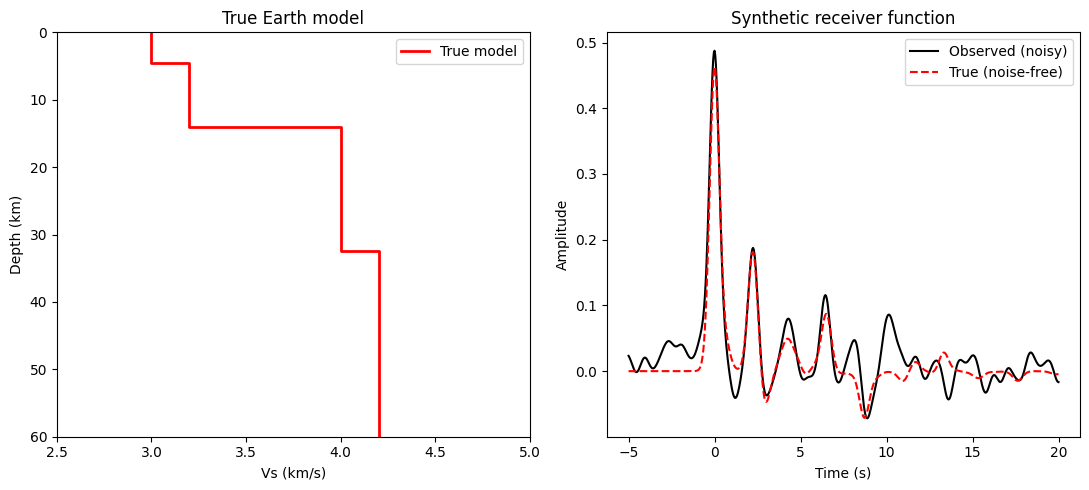

In [7]:
# Plot the true model and observed data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

# Velocity-depth profile
plot_model_staircase(good_model, ax1, color="red", lw=2, label="True model")
ax1.set_xlim(2.5, 5.0)
ax1.set_ylim(60, 0)
ax1.set_xlabel("Vs (km/s)")
ax1.set_ylabel("Depth (km)")
ax1.set_title("True Earth model")
ax1.legend()

# Receiver functions
ax2.plot(t2, rfunc_noise, color="k", label="Observed (noisy)")
ax2.plot(t, rfunc, color="r", ls="--", label="True (noise-free)")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Amplitude")
ax2.set_title("Synthetic receiver function")
ax2.legend()

plt.tight_layout()

***

## 4. Problem 1: Invert for velocities only <a name="problem1"></a>

In this first problem we fix the layer depths at their true values and invert only
for the 4 S-wave velocities. This is a simpler 4-dimensional problem.

In [8]:
# Conversion functions for velocity-only inversion
fixed_depths = good_model[:, 0]  # [1, 8, 20, 45] — held fixed

def get_vel_params(fullmodel):
    """Extract velocity parameters from full model."""
    return fullmodel[:, 1].copy()

def make_model_vel(vel_params):
    """Reconstruct full model from velocity parameters (fixed depths and Vp/Vs)."""
    return np.column_stack([fixed_depths, vel_params, vpvs])

# Misfit function for velocity-only inversion (used by Stage I)
def misfit_vel(vel_params):
    model = make_model_vel(vel_params)
    t_pred, predicted_data = pyrf96.rfcalc(model)
    res = observed_data - predicted_data
    misfit_val = np.dot(res, np.transpose(np.dot(Cdinv, res))) / 2.0
    if math.isnan(misfit_val):
        return float("inf")
    return misfit_val

# Log posterior function (used by Stage II)
def log_posterior_vel(vel_params):
    """Log posterior = -misfit (uniform prior, Gaussian likelihood)."""
    return -misfit_vel(vel_params)

# CoFI BaseProblem
inv_problem_vel = BaseProblem()
inv_problem_vel.name = "Receiver Function - Velocity only"
inv_problem_vel.set_objective(misfit_vel)
inv_problem_vel.summary()

Summary for inversion problem: Receiver Function - Velocity only
Model shape: Unknown
---------------------------------------------------------------------
List of functions/properties set by you:
['objective']
---------------------------------------------------------------------
List of functions/properties created based on what you have provided:
-- none --
---------------------------------------------------------------------
List of functions/properties that can be further set for the problem:
( not all of these may be relevant to your inversion workflow )
['log_posterior', 'log_posterior_with_blobs', 'log_likelihood', 'log_prior', 'gradient', 'hessian', 'hessian_times_vector', 'residual', 'jacobian', 'jacobian_times_vector', 'data_misfit', 'regularization', 'regularization_matrix', 'forward', 'data', 'data_covariance', 'data_covariance_inv', 'initial_model', 'model_shape', 'blobs_dtype', 'bounds', 'constraints']


### 4.1 Stage I: Direct Search <a name="p1-stage1"></a>

Stage I of the Neighbourhood Algorithm is a derivative-free ensemble optimiser.
It minimises the misfit function defined above by iteratively sampling new models
in the neighbourhood of the best-fitting models found so far. The `neighpyI` tool
in CoFI runs only this direct search phase.

In [9]:
# NA-I hyperparameters for 4-D problem
bounds_vel = [(2.0, 4.5)] * 4

inv_options_vel = InversionOptions()
inv_options_vel.set_tool("neighpyI")
inv_options_vel.set_params(
    bounds=bounds_vel,
    n_initial_samples=2000,
    n_samples_per_iteration=50,
    n_cells_to_resample=10,
    n_iterations=100,
)

inv_vel = Inversion(inv_problem_vel, inv_options_vel)
inv_result_vel = inv_vel.run()
inv_result_vel.summary()

NAI - Initial Random Search


NAI - Optimisation Loop: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:04<00:00, 20.76it/s]


Summary for inversion result
SUCCESS
----------------------------
model: [3.05523934 3.13829041 4.04271246 4.23493446]
samples: [[3.94165669 4.13019025 3.7340608  4.2243027 ]
 [4.2788491  2.4323786  3.78734299 3.05658044]
 [4.34404499 2.65223254 4.48311769 2.95112656]
 ...
 [3.05523934 3.13829042 4.04271246 4.23493446]
 [3.05523934 3.13829042 4.04271246 4.23493446]
 [3.05523934 3.13829042 4.04271246 4.23493446]]
objectives: [1595.62936081 3541.12830105 5610.32676343 ...  381.27784216  381.27784216
  381.27784216]


In [10]:
best_vel = inv_result_vel.model
ds_samples_vel = inv_result_vel.samples
ds_objectives_vel = inv_result_vel.objectives

print("Best model (velocities):")
print(make_model_vel(best_vel))
print("\nTrue model:")
print(good_model)

Best model (velocities):
[[ 1.          3.05523934  1.7       ]
 [ 8.          3.13829041  2.        ]
 [20.          4.04271246  1.7       ]
 [45.          4.23493446  1.7       ]]

True model:
[[ 1.   3.   1.7]
 [ 8.   3.2  2. ]
 [20.   4.   1.7]
 [45.   4.2  1.7]]


#### Convergence

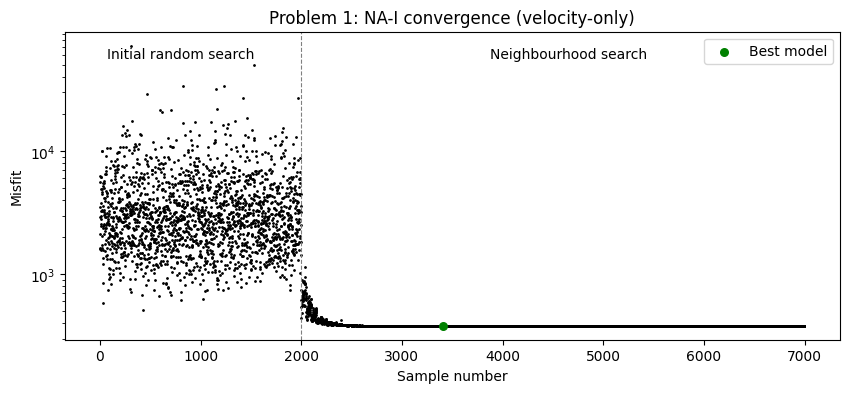

In [11]:
best_i_vel = np.argmin(ds_objectives_vel)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ds_objectives_vel, marker=".", linestyle="", markersize=2, color="black")
ax.scatter(best_i_vel, ds_objectives_vel[best_i_vel], c="g", s=30, zorder=10,
           label="Best model")
ax.axvline(2000, c="grey", ls="--", lw=0.8)
ax.set_yscale("log")
ax.set_xlabel("Sample number")
ax.set_ylabel("Misfit")
ax.set_title("Problem 1: NA-I convergence (velocity-only)")
ax.text(0.15, 0.95, "Initial random search", transform=ax.transAxes,
        ha="center", va="top")
ax.text(0.65, 0.95, "Neighbourhood search", transform=ax.transAxes,
        ha="center", va="top")
ax.legend()

#### NA-I model ensemble

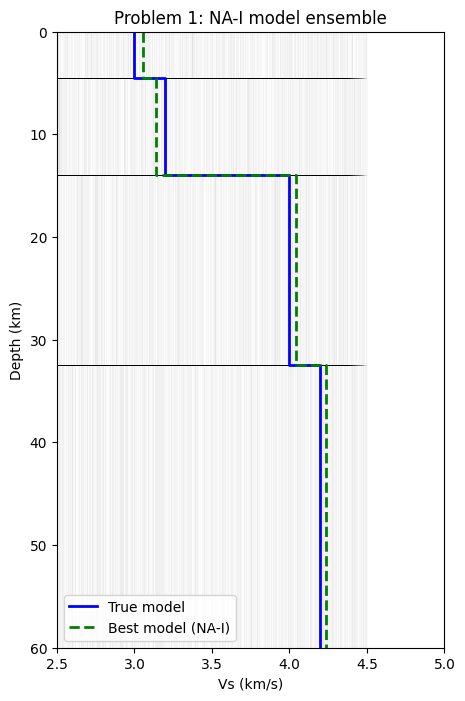

In [12]:
fig, ax = plt.subplots(figsize=(5, 8))

# Plot initial random samples as faint ensemble
for i in range(min(2000, len(ds_samples_vel))):
    m = make_model_vel(ds_samples_vel[i])
    plot_model_staircase(m, ax, color="k", alpha=0.01, lw=0.5)

plot_model_staircase(good_model, ax, color="b", lw=2, label="True model")
plot_model_staircase(make_model_vel(best_vel), ax, color="g", lw=2, ls="--",
                     label="Best model (NA-I)")
ax.set_xlim(2.5, 5.0)
ax.set_ylim(60, 0)
ax.set_xlabel("Vs (km/s)")
ax.set_ylabel("Depth (km)")
ax.set_title("Problem 1: NA-I model ensemble")
ax.legend(loc="lower left")

#### NA-I predicted data

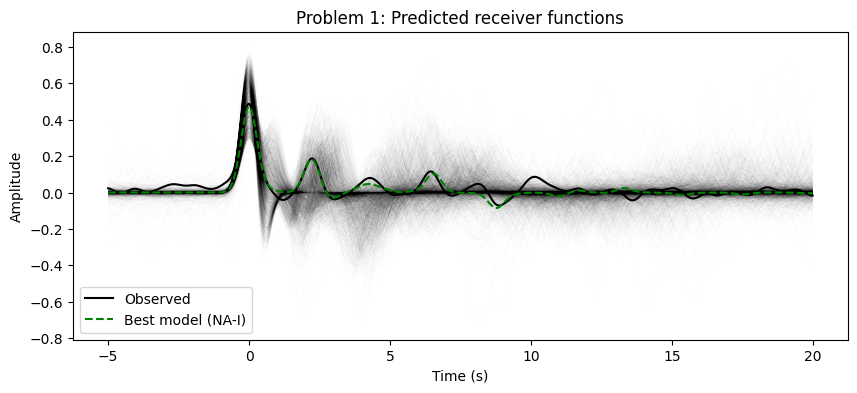

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))

# Plot predicted RFs from initial samples
for i in range(min(2000, len(ds_samples_vel))):
    m = make_model_vel(ds_samples_vel[i])
    try:
        t_pred, rf_pred = pyrf96.rfcalc(m)
        ax.plot(t_pred, rf_pred, color="k", alpha=0.01, lw=0.5)
    except Exception:
        pass

ax.plot(t2, observed_data, color="k", lw=1.5, label="Observed", zorder=10)
t_best, rf_best = pyrf96.rfcalc(make_model_vel(best_vel))
ax.plot(t_best, rf_best, color="g", ls="--", lw=1.5, label="Best model (NA-I)",
        zorder=11)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title("Problem 1: Predicted receiver functions")
ax.legend()

### 4.2 Stage II: Appraisal <a name="p1-stage2"></a>

Stage II of the NA resamples the Voronoi cells constructed by Stage I according
to a **log posterior probability density** (log-PPD). Crucially, this stage
requires no additional forward model evaluations — it only uses the geometry of
the Stage I ensemble and the log-PPD values assigned to each sample.

The user must provide `log_ppd` values for each sample in the Stage I ensemble.
The relationship between the log-PPD and the misfit is a **modelling choice**:

$$\log p(\mathbf{m}|\mathbf{d}) = -\Phi(\mathbf{m},\mathbf{d})$$

corresponds to a Gaussian likelihood with a uniform prior. More generally, one
could incorporate a non-uniform prior or a different likelihood function, which
would change the `log_ppd` values without requiring Stage I to be re-run.

In [14]:
# Compute log-PPD for each Stage I sample.
# Since log_posterior_vel(s) = -misfit_vel(s), this is equivalent to:
#   log_ppd_vel = np.array([log_posterior_vel(s) for s in ds_samples_vel])
# but using the already-computed misfit values avoids redundant forward evaluations.
log_ppd_vel = -ds_objectives_vel

In [15]:
# NA-II hyperparameters
inv_options_vel_app = InversionOptions()
inv_options_vel_app.set_tool("neighpyII")
inv_options_vel_app.set_params(
    bounds=bounds_vel,
    initial_ensemble=ds_samples_vel,
    log_ppd=log_ppd_vel,
    n_resample=20000,
    n_walkers=10,
)

inv_vel_app = Inversion(inv_problem_vel, inv_options_vel_app)
inv_result_vel_app = inv_vel_app.run()
inv_result_vel_app.summary()

NAII - Random Walk: 100%|█████████▉| 1993/2000 [00:21<00:00, 106.58it/s]

Summary for inversion result
SUCCESS
----------------------------
new_samples: [[2.9382585  3.11934    3.99574362 4.33647189]
 [3.16377194 3.31833335 4.00592681 4.34240665]
 [3.04067567 3.29286612 3.96318677 4.34588603]
 ...
 [3.02851196 3.12325034 3.89070672 4.45173394]
 [2.88605834 3.16022991 3.87613087 4.44146632]
 [2.84905367 3.15697602 3.89388837 4.44734999]]


NAII - Random Walk: 100%|██████████| 2000/2000 [00:21<00:00, 91.06it/s] 


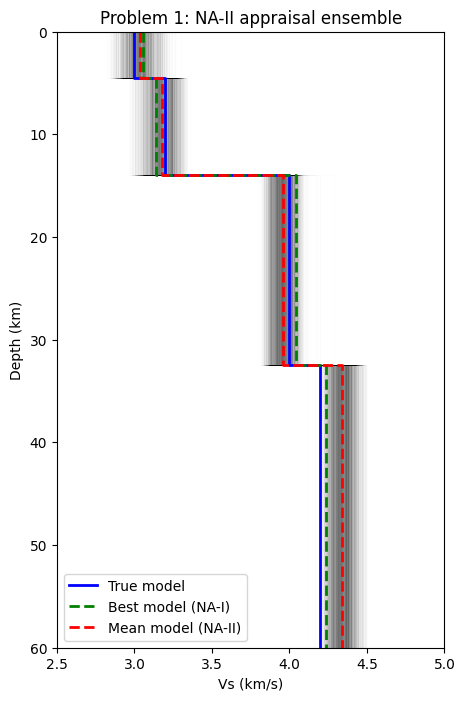

In [16]:
appraisal_samples_vel = inv_result_vel_app.new_samples
appraisal_mean_vel = appraisal_samples_vel.mean(axis=0)

fig, ax = plt.subplots(figsize=(5, 8))
for i in range(0, len(appraisal_samples_vel), 10):
    m = make_model_vel(appraisal_samples_vel[i])
    plot_model_staircase(m, ax, color="k", alpha=0.01, lw=0.5)

plot_model_staircase(good_model, ax, color="b", lw=2, label="True model")
plot_model_staircase(make_model_vel(best_vel), ax, color="g", lw=2, ls="--",
                     label="Best model (NA-I)")
plot_model_staircase(make_model_vel(appraisal_mean_vel), ax, color="r", lw=2,
                     ls="--", label="Mean model (NA-II)")
ax.set_xlim(2.5, 5.0)
ax.set_ylim(60, 0)
ax.set_xlabel("Vs (km/s)")
ax.set_ylabel("Depth (km)")
ax.set_title("Problem 1: NA-II appraisal ensemble")
ax.legend(loc="lower left")

Text(0.5, 0.98, 'Problem 1: Posterior corner plot (velocity-only)')

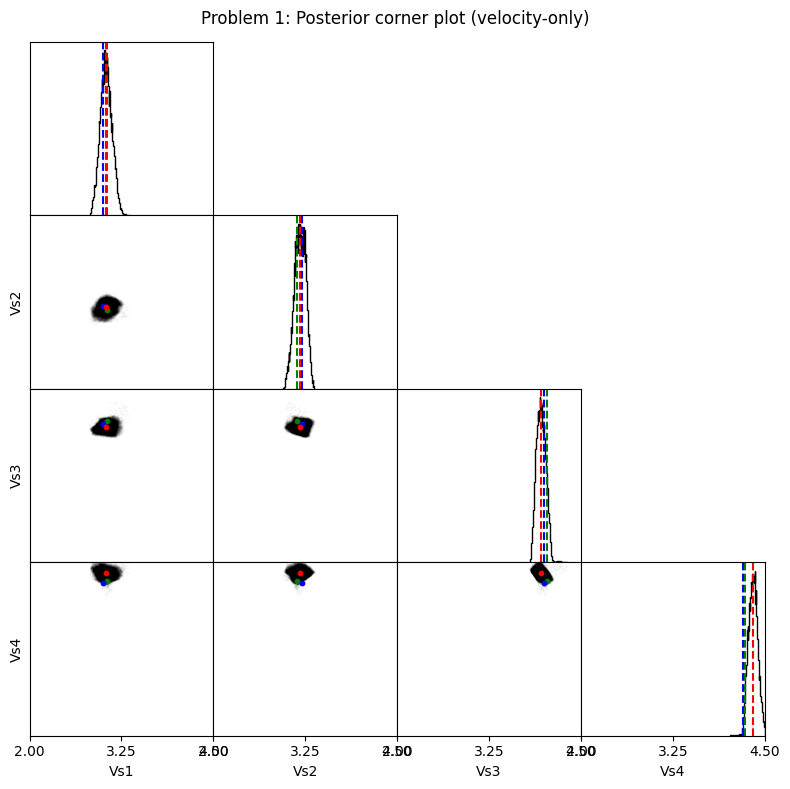

In [17]:
# 4x4 corner plot for velocity-only problem
true_vel = get_vel_params(good_model)
n_params_vel = 4
var_names_vel = [f"Vs{i+1}" for i in range(n_params_vel)]

fig, axes = plt.subplots(n_params_vel, n_params_vel, figsize=(8, 8),
                         tight_layout=True,
                         gridspec_kw={"hspace": 0, "wspace": 0})
for i in range(n_params_vel):
    for j in range(n_params_vel):
        axes[i, j].set_xlim(bounds_vel[j])
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
        if i == j:
            axes[i, j].hist(appraisal_samples_vel[:, j], bins=100,
                            histtype="step", color="k")
            axes[i, j].axvline(best_vel[j], c="g", ls="--")
            axes[i, j].axvline(true_vel[j], c="b", ls="--")
            axes[i, j].axvline(appraisal_mean_vel[j], c="r", ls="--")
        elif j < i:
            axes[i, j].scatter(appraisal_samples_vel[:, j],
                               appraisal_samples_vel[:, i],
                               s=1, c="k", alpha=0.01)
            axes[i, j].scatter(best_vel[j], best_vel[i], c="g", s=10, zorder=10)
            axes[i, j].scatter(true_vel[j], true_vel[i], c="b", s=10, zorder=10)
            axes[i, j].scatter(appraisal_mean_vel[j], appraisal_mean_vel[i],
                               c="r", s=10, zorder=10)
            axes[i, j].set_ylim(bounds_vel[i])
        else:
            axes[i, j].axis("off")
        if i == n_params_vel - 1 and j <= i:
            axes[i, j].set_xlabel(var_names_vel[j])
            axes[i, j].set_xticks(np.linspace(*bounds_vel[j], 3))
        if j == 0 and i > 0:
            axes[i, j].set_ylabel(var_names_vel[i])

fig.suptitle("Problem 1: Posterior corner plot (velocity-only)")

***

## 5. Problem 2: Invert for depths and velocities <a name="problem2"></a>

Now we invert for both layer depths and S-wave velocities simultaneously.
This is a harder 8-dimensional problem with interleaved parameters:
`[d1, vs1, d2, vs2, d3, vs3, d4, vs4]`.

In [18]:
# Conversion functions for depth+velocity inversion
def get_inversion_parameters(fullmodel):
    """Extract [depth, Vs] pairs as flat 8-vector."""
    return fullmodel[:, :2].flatten()

def get_model_parameters(invmodel):
    """Reconstruct full [4,3] model from 8-vector, restoring fixed Vp/Vs."""
    return np.append(invmodel.reshape(len(vpvs), -1), vpvs[:, None], axis=1)

# Misfit function for depth+velocity inversion (used by Stage I)
def misfit_dv(imodel):
    model = get_model_parameters(imodel)
    t_pred, predicted_data = pyrf96.rfcalc(model)
    res = observed_data - predicted_data
    misfit_val = np.dot(res, np.transpose(np.dot(Cdinv, res))) / 2.0
    if math.isnan(misfit_val):
        return float("inf")
    return misfit_val

# Log posterior function (used by Stage II)
def log_posterior_dv(imodel):
    """Log posterior = -misfit (uniform prior, Gaussian likelihood)."""
    return -misfit_dv(imodel)

# CoFI BaseProblem
inv_problem_dv = BaseProblem()
inv_problem_dv.name = "Receiver Function - Depth + Velocity"
inv_problem_dv.set_objective(misfit_dv)
inv_problem_dv.summary()

Summary for inversion problem: Receiver Function - Depth + Velocity
Model shape: Unknown
---------------------------------------------------------------------
List of functions/properties set by you:
['objective']
---------------------------------------------------------------------
List of functions/properties created based on what you have provided:
-- none --
---------------------------------------------------------------------
List of functions/properties that can be further set for the problem:
( not all of these may be relevant to your inversion workflow )
['log_posterior', 'log_posterior_with_blobs', 'log_likelihood', 'log_prior', 'gradient', 'hessian', 'hessian_times_vector', 'residual', 'jacobian', 'jacobian_times_vector', 'data_misfit', 'regularization', 'regularization_matrix', 'forward', 'data', 'data_covariance', 'data_covariance_inv', 'initial_model', 'model_shape', 'blobs_dtype', 'bounds', 'constraints']


### 5.1 Stage I: Direct Search <a name="p2-stage1"></a>

In [19]:
# NA-I hyperparameters for 8-D problem (larger than Problem 1)
bounds_dv = [(0.0, 60.0), (2.0, 4.5)] * 4

inv_options_dv = InversionOptions()
inv_options_dv.set_tool("neighpyI")
inv_options_dv.set_params(
    bounds=bounds_dv,
    n_initial_samples=2000,
    n_samples_per_iteration=100,
    n_cells_to_resample=20,
    n_iterations=50,
)

inv_dv = Inversion(inv_problem_dv, inv_options_dv)
inv_result_dv = inv_dv.run()
inv_result_dv.summary()

NAI - Initial Random Search


NAI - Optimisation Loop: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:03<00:00, 14.85it/s]


Summary for inversion result
SUCCESS
----------------------------
model: [34.73477042  4.1568739   7.06327753  3.1907339  47.54177016  4.09688282
 21.88630065  3.97501905]
samples: [[27.61379832  4.42816175 38.90307861 ...  2.90552352 11.01480963
   3.72662425]
 [52.87834007  2.28083958 23.78810008 ...  2.0420744  34.03185551
   4.43812554]
 [30.20701483  2.02047406 16.93312253 ...  3.52271457 27.7338207
   2.55748653]
 ...
 [34.50293046  4.15877616  7.03393792 ...  4.10232154 21.89974943
   3.97052374]
 [34.49990258  4.16072688  7.03390338 ...  4.10220406 21.89432352
   3.97233653]
 [34.50248974  4.16024307  7.03195344 ...  4.10108064 21.88772662
   3.97250707]]
objectives: [ 5615.05569862 12744.4688834   1848.73121172 ...   440.13583517
   439.96125146   439.79821626]


In [20]:
best_dv = inv_result_dv.model
ds_samples_dv = inv_result_dv.samples
ds_objectives_dv = inv_result_dv.objectives

print("Best model (depth + velocity):")
print(get_model_parameters(best_dv))
print("\nTrue model:")
print(good_model)

Best model (depth + velocity):
[[34.73477042  4.1568739   1.7       ]
 [ 7.06327753  3.1907339   2.        ]
 [47.54177016  4.09688282  1.7       ]
 [21.88630065  3.97501905  1.7       ]]

True model:
[[ 1.   3.   1.7]
 [ 8.   3.2  2. ]
 [20.   4.   1.7]
 [45.   4.2  1.7]]


#### Convergence

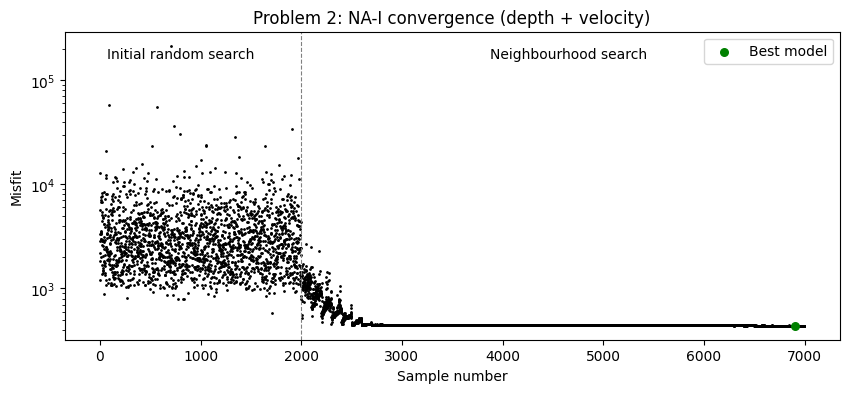

In [21]:
best_i_dv = np.argmin(ds_objectives_dv)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ds_objectives_dv, marker=".", linestyle="", markersize=2, color="black")
ax.scatter(best_i_dv, ds_objectives_dv[best_i_dv], c="g", s=30, zorder=10,
           label="Best model")
ax.axvline(2000, c="grey", ls="--", lw=0.8)
ax.set_yscale("log")
ax.set_xlabel("Sample number")
ax.set_ylabel("Misfit")
ax.set_title("Problem 2: NA-I convergence (depth + velocity)")
ax.text(0.15, 0.95, "Initial random search", transform=ax.transAxes,
        ha="center", va="top")
ax.text(0.65, 0.95, "Neighbourhood search", transform=ax.transAxes,
        ha="center", va="top")
ax.legend()

### 5.2 Stage II: Appraisal <a name="p2-stage2"></a>

In [22]:
# Compute log-PPD for each Stage I sample (same choice as Problem 1)
log_ppd_dv = -ds_objectives_dv

In [23]:
# NA-II hyperparameters
inv_options_dv_app = InversionOptions()
inv_options_dv_app.set_tool("neighpyII")
inv_options_dv_app.set_params(
    bounds=bounds_dv,
    initial_ensemble=ds_samples_dv,
    log_ppd=log_ppd_dv,
    n_resample=20000,
    n_walkers=10,
)

inv_dv_app = Inversion(inv_problem_dv, inv_options_dv_app)
inv_result_dv_app = inv_dv_app.run()
inv_result_dv_app.summary()

NAII - Random Walk:  99%|█████████▉| 1976/2000 [00:33<00:00, 57.20it/s]s]

Summary for inversion result
SUCCESS
----------------------------
new_samples: [[42.48765473  4.07569891  2.29104991 ...  4.16197482 19.42096359
   4.07291501]
 [40.60204402  4.21403755 13.79593877 ...  4.41791981 18.47483972
   4.2509982 ]
 [47.53852731  4.24621116  4.12930939 ...  4.47407036 18.6723048
   4.30487004]
 ...
 [51.74760989  4.28792695 10.06861454 ...  4.35322899 23.26826654
   4.05354626]
 [51.8767336   4.30862488  6.08128347 ...  4.11538525 20.95684572
   3.95548709]
 [48.62651632  4.1401062   4.58180119 ...  3.96484453 12.27449371
   3.97635049]]


NAII - Random Walk: 100%|██████████| 2000/2000 [00:34<00:00, 58.54it/s]


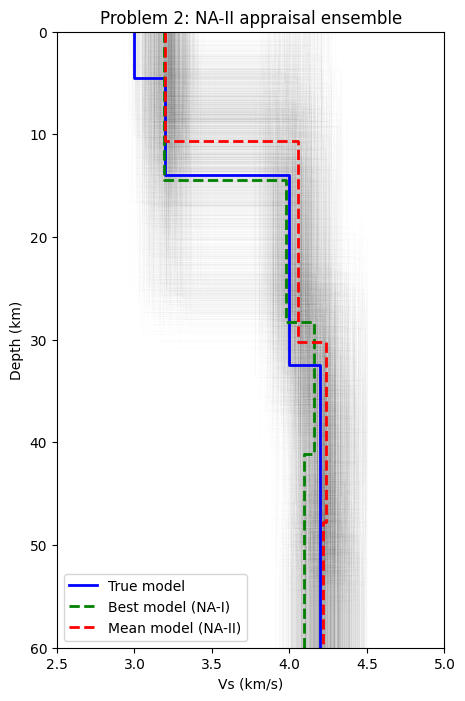

In [24]:
appraisal_samples_dv = inv_result_dv_app.new_samples
appraisal_mean_dv = appraisal_samples_dv.mean(axis=0)

fig, ax = plt.subplots(figsize=(5, 8))
for i in range(0, len(appraisal_samples_dv), 10):
    m = get_model_parameters(appraisal_samples_dv[i])
    plot_model_staircase(m, ax, color="k", alpha=0.01, lw=0.5)

plot_model_staircase(good_model, ax, color="b", lw=2, label="True model")
plot_model_staircase(get_model_parameters(best_dv), ax, color="g", lw=2,
                     ls="--", label="Best model (NA-I)")
plot_model_staircase(get_model_parameters(appraisal_mean_dv), ax, color="r",
                     lw=2, ls="--", label="Mean model (NA-II)")
ax.set_xlim(2.5, 5.0)
ax.set_ylim(60, 0)
ax.set_xlabel("Vs (km/s)")
ax.set_ylabel("Depth (km)")
ax.set_title("Problem 2: NA-II appraisal ensemble")
ax.legend(loc="lower left")

#### Corner plot

Text(0.5, 0.98, 'Problem 2: Posterior corner plot (depth + velocity)')

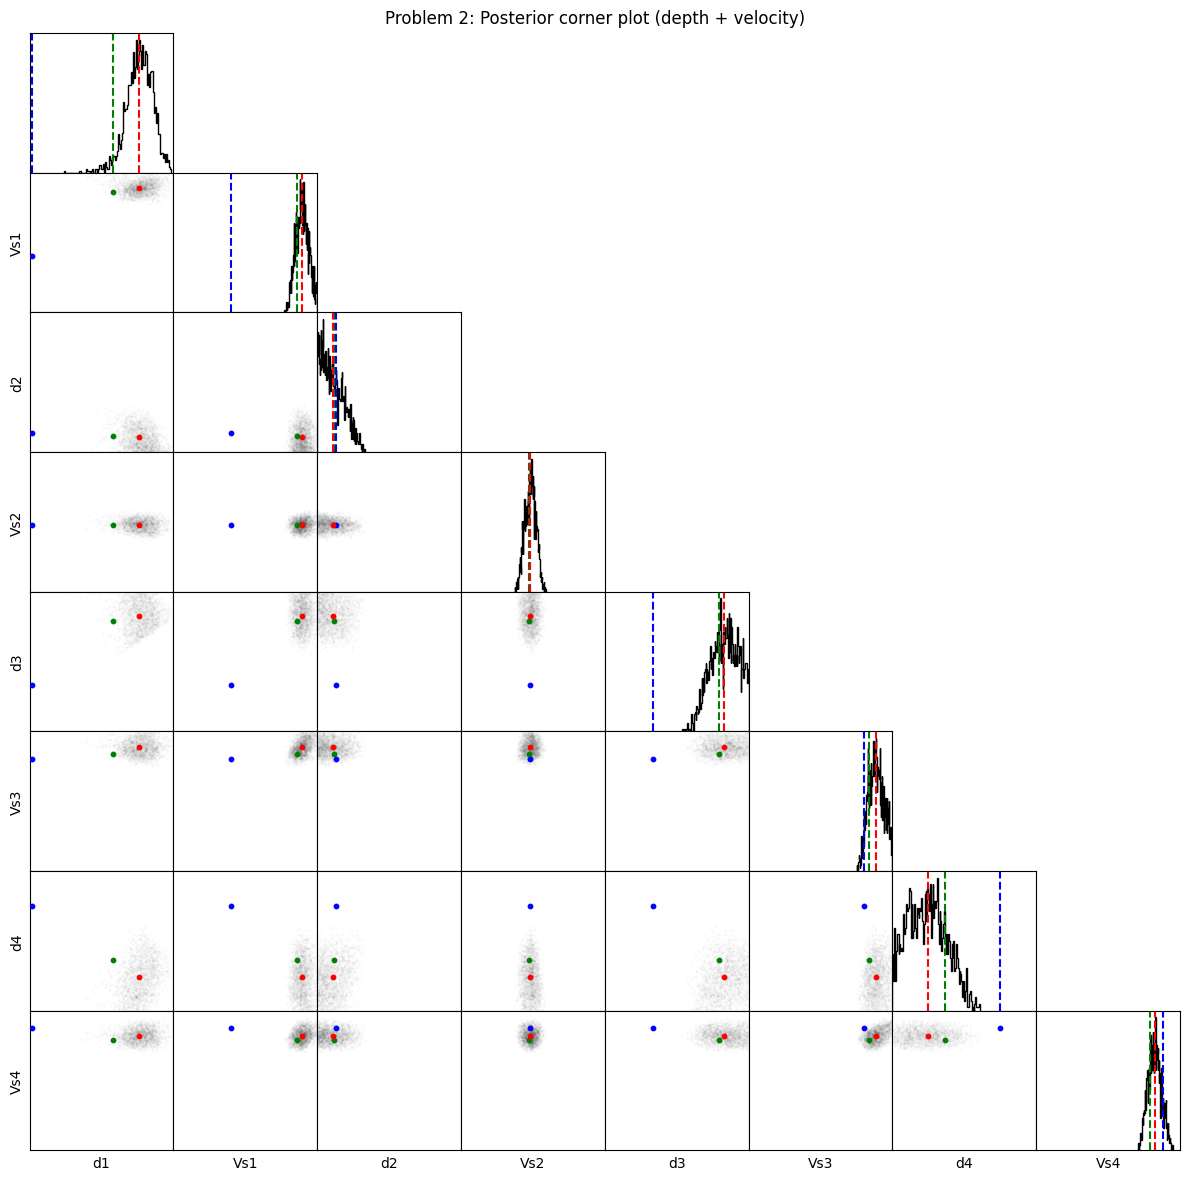

In [25]:
# 8x8 corner plot for depth+velocity problem
true_dv = get_inversion_parameters(good_model)
n_params_dv = 8
var_names_dv = ["d1", "Vs1", "d2", "Vs2", "d3", "Vs3", "d4", "Vs4"]

fig, axes = plt.subplots(n_params_dv, n_params_dv, figsize=(12, 12),
                         tight_layout=True,
                         gridspec_kw={"hspace": 0, "wspace": 0})
for i in range(n_params_dv):
    for j in range(n_params_dv):
        axes[i, j].set_xlim(bounds_dv[j])
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
        if i == j:
            axes[i, j].hist(appraisal_samples_dv[::10, j], bins=100,
                            histtype="step", color="k")
            axes[i, j].axvline(best_dv[j], c="g", ls="--")
            axes[i, j].axvline(true_dv[j], c="b", ls="--")
            axes[i, j].axvline(appraisal_mean_dv[j], c="r", ls="--")
        elif j < i:
            axes[i, j].scatter(appraisal_samples_dv[::10, j],
                               appraisal_samples_dv[::10, i],
                               s=1, c="k", alpha=0.01)
            axes[i, j].scatter(best_dv[j], best_dv[i], c="g", s=10, zorder=10)
            axes[i, j].scatter(true_dv[j], true_dv[i], c="b", s=10, zorder=10)
            axes[i, j].scatter(appraisal_mean_dv[j], appraisal_mean_dv[i],
                               c="r", s=10, zorder=10)
            axes[i, j].set_ylim(bounds_dv[i])
        else:
            axes[i, j].axis("off")

for ax_, xlabel in zip(axes[-1, :], var_names_dv):
    ax_.set_xlabel(xlabel)
for ax_, ylabel in zip(axes[:, 0], var_names_dv):
    if ylabel != var_names_dv[0]:
        ax_.set_ylabel(ylabel)

fig.suptitle("Problem 2: Posterior corner plot (depth + velocity)")

#### Predicted data ensemble

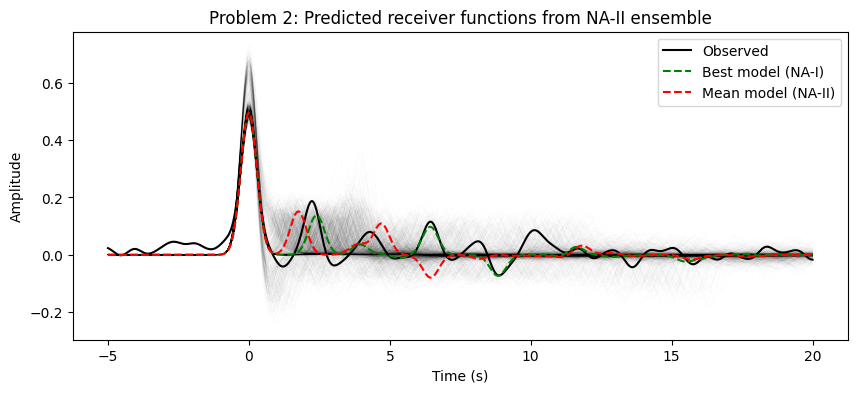

In [26]:
fig, ax = plt.subplots(figsize=(10, 4))

for i in range(0, len(appraisal_samples_dv), 15):
    m = get_model_parameters(appraisal_samples_dv[i])
    try:
        t_pred, rf_pred = pyrf96.rfcalc(m)
        ax.plot(t_pred, rf_pred, color="k", alpha=0.01, lw=0.5)
    except Exception:
        pass

ax.plot(t2, observed_data, color="k", lw=1.5, label="Observed", zorder=10)
t_best, rf_best = pyrf96.rfcalc(get_model_parameters(best_dv))
ax.plot(t_best, rf_best, color="g", ls="--", lw=1.5, label="Best model (NA-I)",
        zorder=11)
t_mean, rf_mean = pyrf96.rfcalc(get_model_parameters(appraisal_mean_dv))
ax.plot(t_mean, rf_mean, color="r", ls="--", lw=1.5, label="Mean model (NA-II)",
        zorder=11)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title("Problem 2: Predicted receiver functions from NA-II ensemble")
ax.legend()

***

## Watermark

In [27]:
watermark_list = ["cofi", "numpy", "scipy", "matplotlib"]
for pkg in watermark_list:
    pkg_var = __import__(pkg)
    print(pkg, getattr(pkg_var, "__version__"))

cofi 0.2.10
numpy 2.3.5
scipy 1.16.3
matplotlib 3.10.7
